In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# loading in trained PC scores, labels and explained ratio
pcScores_train = np.load("pcScores_train.npy", allow_pickle = True)
labels_train = np.load("pc_geoRegion_labels_train.npy", allow_pickle = True)
explainedRatio = np.load("PCAexplainedRatio.npy", allow_pickle = True)
pcScores = pcScores_train
labels = labels_train

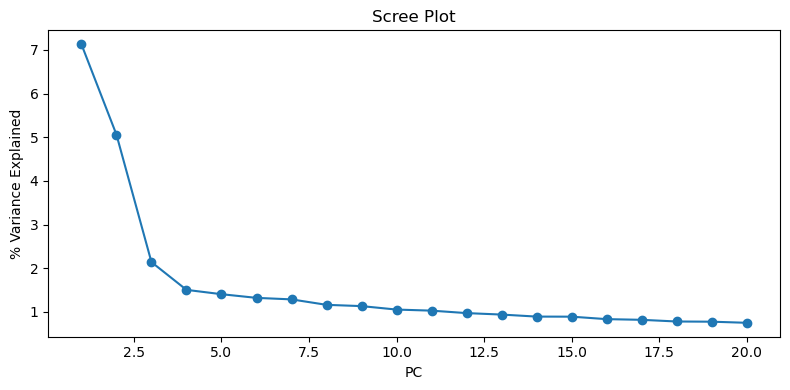

In [10]:
# scree plot — should see an elbow after the first few meaningful PCs
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(range(1, 21), explainedRatio[:20] * 100, 'o-')
ax.set_xlabel("PC")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree Plot")
plt.tight_layout()
plt.show()

In [11]:
# PC1 mean per region — Africa should be separated from other regions
print("PC1 mean by region:")
for region in np.unique(labels):
    mask = labels == region
    print(f"{region}: {pcScores[mask, 0].mean():.2f}")

PC1 mean by region:
AFRICA: -34.27
AMERICA: 14.09
CENTRAL_SOUTH_ASIA: 10.70
EAST_ASIA: 11.55
EUROPE: 14.24
MIDDLE_EAST: 4.05
OCEANIA: 2.34


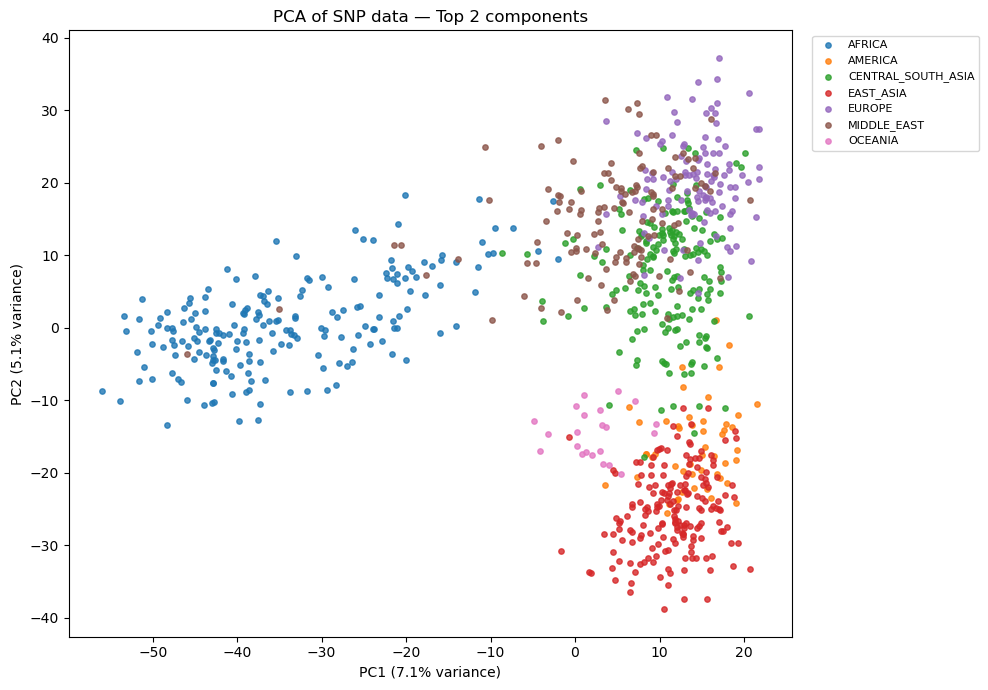

In [12]:
# PC1 vs PC2 — Africa should be isolated on PC1 & Europe/East Asia separated on PC2

fig, ax = plt.subplots(figsize=(10, 7))

for region in np.unique(labels):
    # finding which rows in labels correspond to each region and plotting those rows in pcScores
    mask = labels == region
    ax.scatter(pcScores[mask, 0], pcScores[mask, 1], label=region, s=15, alpha=0.8)

ax.set_xlabel(f"PC1 ({explainedRatio[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explainedRatio[1] * 100:.1f}% variance)")
ax.set_title("PCA of SNP data — Top 2 components")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

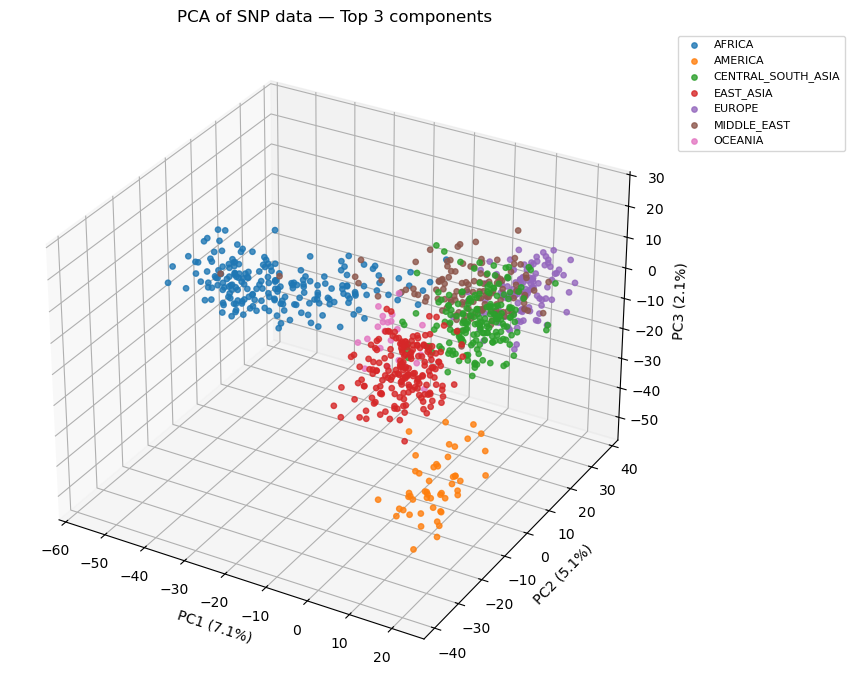

In [13]:
# 3D PCA plot — PC1 vs PC2 vs PC3

fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection="3d")

for region in np.unique(labels):
    mask = labels == region
    ax3d.scatter(pcScores[mask, 0], pcScores[mask, 1], pcScores[mask, 2],
                 label=region, s=15, alpha=0.8)

ax3d.set_xlabel(f"PC1 ({explainedRatio[0] * 100:.1f}%)")
ax3d.set_ylabel(f"PC2 ({explainedRatio[1] * 100:.1f}%)")
ax3d.set_zlabel(f"PC3 ({explainedRatio[2] * 100:.1f}%)")
ax3d.set_title("PCA of SNP data — Top 3 components")
ax3d.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()